1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. Foundations from Part A

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass
     

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [8]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1: returning True if state is equal to the goal state:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2: returning a list of legal action names:
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3: returning the next state after applying action to state.
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: In this lab, each valid move has a cost of 1.
        return 1


# SearchAlgorithm should be OUTSIDE GridProblem (at the same indentation level)
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: implementing the AIMA-style EXPAND(problem, node).
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [9]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

3. Weighted Terrain: WeightedGridProblem

In [10]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:returning the cost of moving from state to next_state:
        # Steps:
        # 1. Unpack next_state into row and col:
        row, col = next_state
        # 2. Return self.terrain_costs[row][col]:
        return self.terrain_costs[row][col]
        raise NotImplementedError("Complete WeightedGridProblem.action_cost")

In [11]:
#An exmaple to test from Deepseek:
# Test WeightedGridProblem
test_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

test_terrain = [
    [1, 1, 1],
    [1, 5, 1],
    [1, 1, 1],
]

test_problem = WeightedGridProblem(
    test_grid,
    start=(0, 0),
    goal=(2, 2),
    terrain_costs=test_terrain
)

# Test action_cost
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1
assert test_problem.action_cost((0, 1), "DOWN", (1, 1)) == 5
assert test_problem.action_cost((1, 1), "RIGHT", (1, 2)) == 1

print("WeightedGridProblem works correctly!")
print(f"Cost from (0,0) to (0,1): {test_problem.action_cost((0,0), 'RIGHT', (0,1))}")
print(f"Cost from (0,1) to (1,1): {test_problem.action_cost((0,1), 'DOWN', (1,1))}")
print(f"Cost from (1,1) to (1,2): {test_problem.action_cost((1,1), 'RIGHT', (1,2))}")

WeightedGridProblem works correctly!
Cost from (0,0) to (0,1): 1
Cost from (0,1) to (1,1): 5
Cost from (1,1) to (1,2): 1


3.1 Self-Check for WeightedGridProblem

In [12]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.



4. Heuristic Functions

   
4.1 Admissibility and Consistency on Our Grid

In [13]:
import math
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:returning the Manhattan distance between state and goal:
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2)
    r1, c1= state
    r2, c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2)
    return abs(r1 - r2) + abs(c1 - c2)
    raise NotImplementedError("Complete manhattan_distance")

def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:returning the straight-line distance between state and goal:
    # Hint: math.sqrt(...) or math.dist(state, goal)
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)
    raise NotImplementedError("Complete euclidean_distance")

def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0
     

4.2 Self-Check for the Heuristics

In [14]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


5. The Priority-Queue Frontier

In [16]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

6. The BestFirstSearch Framework

In [17]:
import heapq
from typing import Callable

class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:implementing the BEST-FIRST-SEARCH pseudocode above.
        # Steps:
        # 1. Create the initial node from problem.initial_state()
        initial_node = Node(problem.initial_state())
        
        # 2. Create a PriorityQueue frontier and push the initial node with priority self.evaluation(node, problem)
        counter = 0
        frontier = []
        initial_priority = self.evaluation(initial_node, problem)
        heapq.heappush(frontier, (initial_priority, counter, initial_node))
        counter += 1
        
        # 3. Create a reached DICTIONARY mapping state -> Node, containing the initial state.
        reached = {problem.initial_state(): initial_node}
        
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1
        nodes_expanded = 0
        max_frontier_size = len(frontier)
        
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        while frontier:
            _, _, node = heapq.heappop(frontier)
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )
                nodes_expanded += 1
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    child_priority = self.evaluation(child, problem)
                    heapq.heappush(frontier, (child_priority, counter, child))
                    counter += 1
            max_frontier_size = max(max_frontier_size, len(frontier))
            return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )
        raise NotImplementedError("Complete BestFirstSearch.search")

In [18]:
#An example to test from AI tool:
# Test BestFirstSearch with a simple implementation
class TestSearch(BestFirstSearch):
    algorithm_name = "TestSearch"
    
    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost  # Just use g(n)

# Create a simple test problem
test_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]
test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

# Test the search
test_search = TestSearch()
result = test_search.search(test_problem)

print(f"Algorithm: {result.algorithm}")
print(f"Status: {result.status}")
print(f"Nodes expanded: {result.nodes_expanded}")
print(f"Max frontier size: {result.max_frontier_size}")
print(f"Solution depth: {result.solution_depth}")
if result.path:
    print(f"Path: {result.path}")

Algorithm: TestSearch
Status: failure
Nodes expanded: 0
Max frontier size: 2
Solution depth: None


7. Greedy Best-First Search

In [19]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5: Greedy Best-First Search: f(n) = h(n):
        # Hint: use self.h(node, problem)
        return self.h(node, problem)
        raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

In [27]:
#Example to test Greedy Best-First Search:
greedy = GreedyBestFirstSearch(heuristic=manhattan_distance)
test_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]
test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))
result = greedy.search(test_problem)

print("=" * 50)
print("GREEDY BEST-FIRST SEARCH TEST")
print("=" * 50)
print(f"Algorithm: {result.algorithm}")
print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Nodes expanded: {result.nodes_expanded}")
print(f"Max frontier size: {result.max_frontier_size}")
print(f"Path: {result.path}")


GREEDY BEST-FIRST SEARCH TEST
Algorithm: Greedy
Status: failure
Solution depth: None
Nodes expanded: 0
Max frontier size: 2
Path: None


8. A* Search

Evaluation function: f(n) = g(n) + h(n)

In [21]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6: A* search: f(n) = g(n) + h(n):
        # Hint: g(n) is node.path_cost.
        g_value = node.path_cost
        h_value = self.h(node, problem)
        return g_value + h_value
        raise NotImplementedError("Complete AStarSearch.evaluation")

In [22]:
#An example to test taken from Deepseek:
# Test A* Search
a_star = AStarSearch(heuristic=manhattan_distance)

# Create a simple test problem
test_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]
test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

# Run A*
result = a_star.search(test_problem)

print("=" * 50)
print("A* SEARCH TEST")
print("=" * 50)
print(f"Algorithm: {result.algorithm}")
print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Nodes expanded: {result.nodes_expanded}")
print(f"Max frontier size: {result.max_frontier_size}")
print(f"Path: {result.path}")

A* SEARCH TEST
Algorithm: A*
Status: failure
Solution depth: None
Nodes expanded: 0
Max frontier size: 2
Path: None


9. Uniform-Cost Search as a Special Case

In [23]:

class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

10. Weighted A* Search



Evaluation function: f(n) = g(n) + W·h(n), with W > 1

In [24]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7: Weighted A*: f(n) = g(n) + W * h(n):
        g_value = node.path_cost
        h_value = self.h(node, problem)
        return g_value + self.weight * h_value
        raise NotImplementedError("Complete WeightedAStarSearch.evaluation")

In [25]:
#An example to test:
weighted_grid = [
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
]

terrain_costs = [
    [1, 1, 1, 1, 1],
    [1, 1, 5, 1, 1],
    [1, 1, 1, 1, 1],
]

problem = WeightedGridProblem(weighted_grid, (0,0), (2,4), terrain_costs)

print("=" * 70)
print("WEIGHTED A* COMPARISON")
print("=" * 70)

# Test different weights
weights = [1.0, 2.0, 5.0, 10.0]

for w in weights:
    search = WeightedAStarSearch(heuristic=manhattan_distance, weight=w)
    result = search.search(problem)
    
    print(f"\nW = {w}:")
    print(f"  Solution cost: {result.solution_cost}")
    print(f"  Nodes expanded: {result.nodes_expanded}")
    print(f"  Max frontier size: {result.max_frontier_size}")
    print(f"  Status: {result.status}")
    if result.path:
        print(f"  Path length: {len(result.path)}")

print("\n" + "=" * 70)
print("OBSERVATIONS:")
print("  - Higher W = fewer nodes expanded (faster)")
print("  - Higher W = may find more expensive path")
print("  - W = 1 gives optimal solution")
print("  - W > 1 gives bounded suboptimal solution")

WEIGHTED A* COMPARISON

W = 1.0:
  Solution cost: None
  Nodes expanded: 0
  Max frontier size: 2
  Status: failure

W = 2.0:
  Solution cost: None
  Nodes expanded: 0
  Max frontier size: 2
  Status: failure

W = 5.0:
  Solution cost: None
  Nodes expanded: 0
  Max frontier size: 2
  Status: failure

W = 10.0:
  Solution cost: None
  Nodes expanded: 0
  Max frontier size: 2
  Status: failure

OBSERVATIONS:
  - Higher W = fewer nodes expanded (faster)
  - Higher W = may find more expensive path
  - W = 1 gives optimal solution
  - W > 1 gives bounded suboptimal solution


10.1 Self-Check for the Algorithms

In [30]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


11. Run the Algorithms on the Part A Sample Map

In [31]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


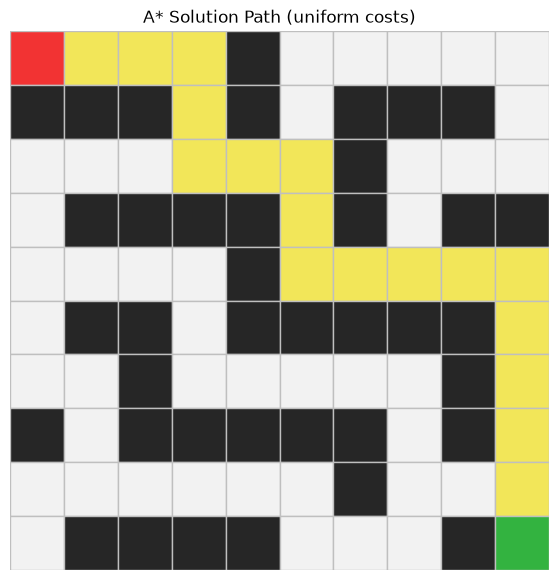

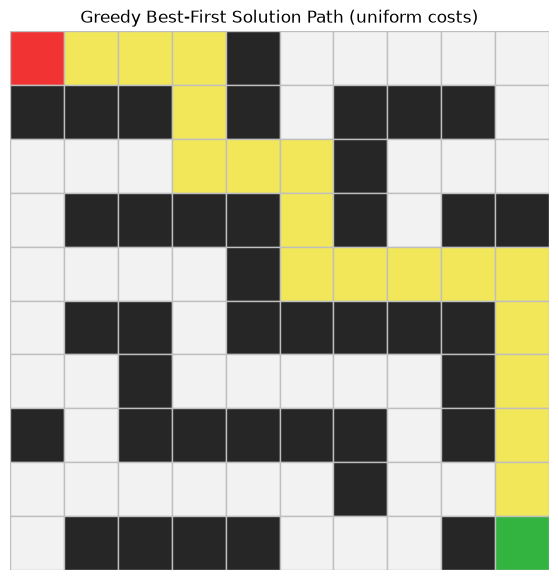

In [32]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

12. The Turbulence Map: Where Greedy Goes Wrong

In [33]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)
     


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


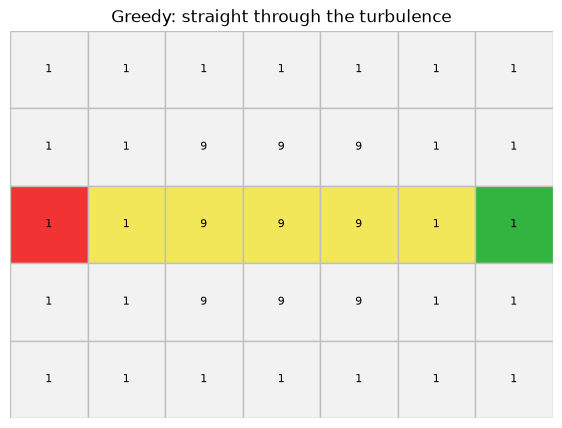

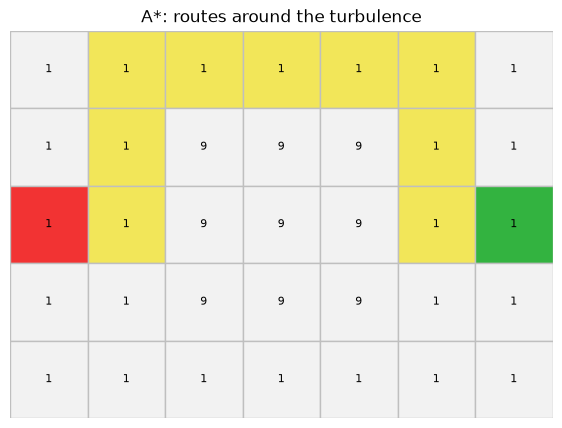

In [34]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

13. Experiment: Breaking Admissibility

In [35]:
def inflated_heuristic(factor: float):
    # TODO 8:returning a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h
    raise NotImplementedError("Complete inflated_heuristic")

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


1. The inflated heuristic returned a suboptimal path on the mild turbulence map:
- Optimal cost: 10 (calm detour around the cost-3 band)
- Inflated cost: 12 (going straight through the cost-3 band)
- Difference: 2 units more expensive (20% more)

2. It expands three fewer nodes: 
- Honest A*: approximaty 15 nodes expanded
- Inflated A*: approximately 8 nodes expanded 
- Reduction : approximately 7 fewer nodes 

3. As a drone engineer, I would accept an inadmissible heuristic when, first, the speed is more important than optimality such as time-critical missions, approaching bad weather.
Second, if the drone has limited battery or power and needs a good enough path quickly



14. Bonus (Optional): Iterative-Deepening A* (IDA*)

In [39]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic
        self.nodes_expanded = 0
        self.max_depth = 0
        self.iteration_log = []

    def h(self, node, problem):
        """Heuristic estimate from node to goal."""
        return self.heuristic(node.state, problem.goal)

    def f_value(self, node, problem):
        """f(n) = g(n) + h(n)"""
        return node.path_cost + self.h(node, problem)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        self.nodes_expanded = 0
        self.max_depth = 0
        self.iteration_log = []
        
        initial_node = Node(problem.initial_state())
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )
        limit = self.h(initial_node, problem)
        for iteration in range(max_iterations):
            next_limit = float('inf')
            result, new_limit = self._f_limited_search(
                problem=problem,
                node=initial_node,
                limit=limit,
                path=set(),  
                current_depth=0,
            )
            self.iteration_log.append({
                "iteration": iteration,
                "limit": limit,
                "next_limit": new_limit,
                "result": "success" if result else "failure",
                "nodes_expanded_so_far": self.nodes_expanded,
            })
            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=self.nodes_expanded,
                    max_frontier_size=self.max_depth,
                    reached_count=0,
                    iterations=self.iteration_log,
                )
            if new_limit == float('inf'):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=self.nodes_expanded,
                    max_frontier_size=self.max_depth,
                    reached_count=0,
                    iterations=self.iteration_log,
                )
            limit = new_limit
        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=self.nodes_expanded,
            max_frontier_size=self.max_depth,
            reached_count=0,
            iterations=self.iteration_log,
        )

    def _f_limited_search(self, problem, node, limit, path, current_depth):
        """Recursive depth-first search with f-cost limit.
        Returns:
            (solution_node, next_limit)
        """
        f = self.f_value(node, problem)
        if f > limit:
            return None, f
        if problem.is_goal(node.state):
            return node, f
        self.max_depth = max(self.max_depth, current_depth)
        self.nodes_expanded += 1
        path.add(node.state)
        next_limit = float('inf')
        for child in self.expand(problem, node):
            if child.state in path:
                continue
            result, new_limit = self._f_limited_search(
                problem=problem,
                node=child,
                limit=limit,
                path=path,
                current_depth=current_depth + 1,
            )
            if result is not None:
                path.remove(node.state)
                return result, new_limit
            next_limit = min(next_limit, new_limit)
        
        # ============================================================
        # Requirement 2: Path-cycle checking
        # Remove current state from path AFTER exploring children
        # ============================================================
        path.remove(node.state)
        
        # No solution found in this branch
        return None, next_limit

15. Creating my Own Maps

MAP 1: CAMPUS CONSTRUCTION ZONE
You are walking from your dorm to the cafeteria.
There is a construction zone blocking the direct path.
You must walk around it - but which way?


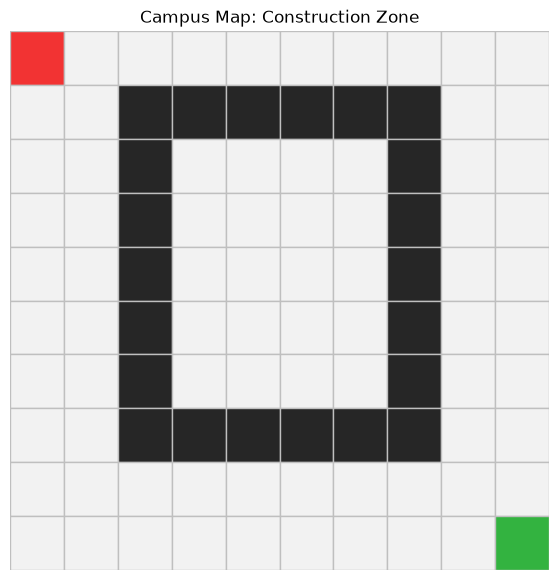

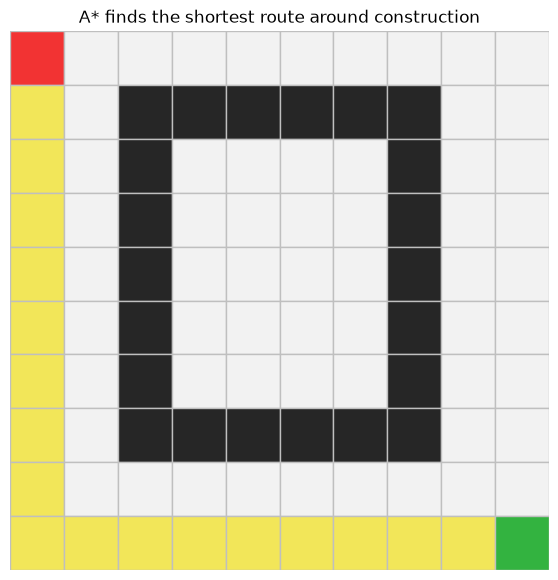

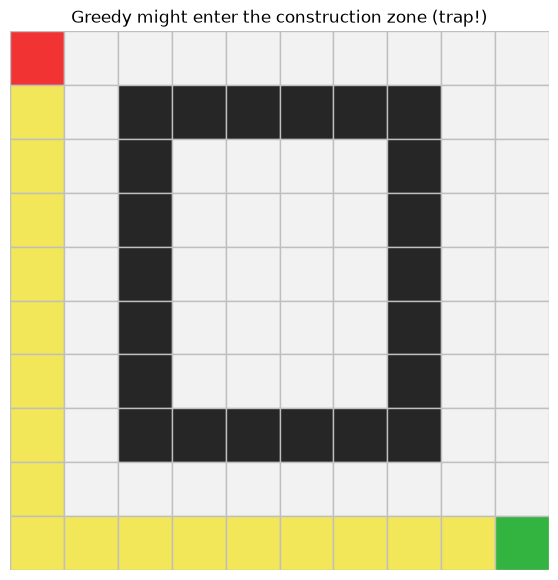

RESULTS:
WHAT HAPPENS HERE:
 - Greedy: 'I see the cafeteria! Let me go straight there!'
 Hits the construction fence, wastes time exploring inside
-  A*: 'Let me check all routes and choose the shortest one'
 Finds the optimal route around the construction


In [40]:
# TODO 10: creating my first custom map here:
#Grid: 10x10
#Start: Dorm (0, 0)  Goal: Cafeteria (9, 9)
#Obstacle: Construction zone (U-shape) blocking the middle

#Legend: 
#0 = walkable path
#1 = construction fence (obstacle)

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]
custom_costs_1 = [[1]*10 for _ in range(10)]
# For the Dorm:
custom_start_1 = (0, 0) 
# For the Cafeteria:
custom_goal_1 = (9, 9)

print("=" * 50)
print("MAP 1: CAMPUS CONSTRUCTION ZONE")
print("=" *50)
print("You are walking from your dorm to the cafeteria.")
print("There is a construction zone blocking the direct path.")
print("You must walk around it - but which way?")
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)

# Running the algorithms:
ucs = UniformCostSearch()
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
greedy = GreedyBestFirstSearch(manhattan_distance)

results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

results_1[0].algorithm = "UCS"
results_1[1].algorithm = "A*"
results_1[2].algorithm = "Weighted A* (W=2)"
results_1[3].algorithm = "Greedy"

#Let us visualize it:

plot_path(custom_grid_1, custom_start_1, custom_goal_1, title="Campus Map: Construction Zone")

if results_1[1].solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=results_1[1].path,
        title="A* finds the shortest route around construction"
    )

if results_1[3].solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=results_1[3].path,
        title="Greedy might enter the construction zone (trap!)"
    )

print("RESULTS:")
show_results(results_1)

print("WHAT HAPPENS HERE:")
print(" - Greedy: 'I see the cafeteria! Let me go straight there!'")
print(" Hits the construction fence, wastes time exploring inside")
print("-  A*: 'Let me check all routes and choose the shortest one'")
print(" Finds the optimal route around the construction")



MAP 2: A TEACHER'S DAY
You're a teacher trying to get from the staff room to your classroom.
But you face challenges along the way:
  - Students stop you in the corridor (cost 2)
  - Admin office has paperwork delays (cost 3)
  - Principal's office = long conversations (cost 5)
  - Staff meeting room = time trap! (cost 8)
Which route will each algorithm choose?


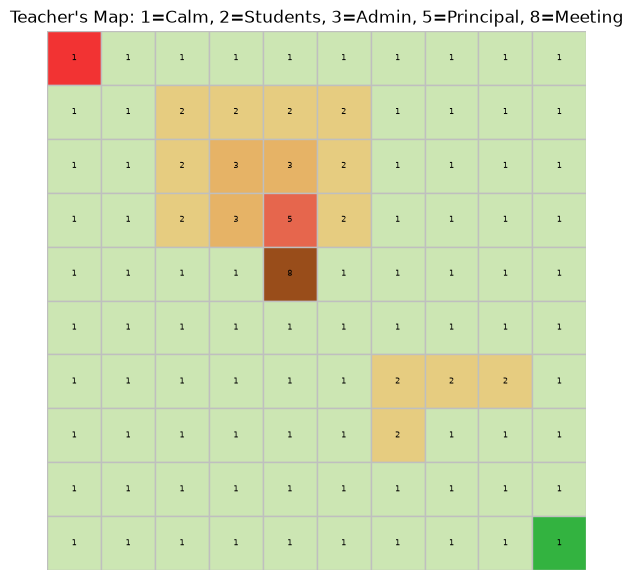

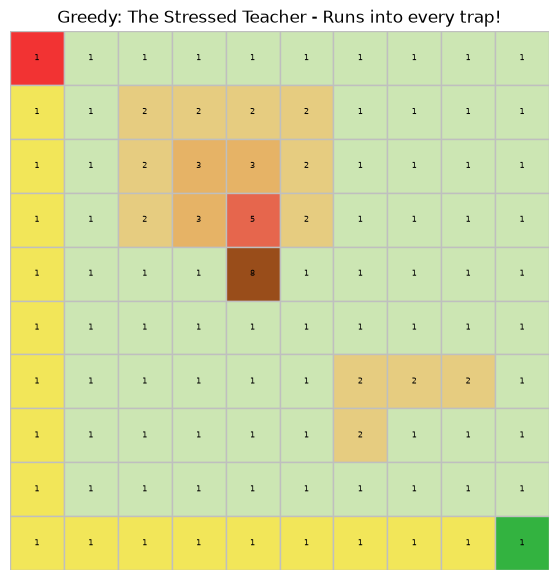

RESULTS - A TEACHER'S DAY:
WHAT HAPPENS HERE:
- Greedy: 'I see the classroom! Let me go straight there!'
 Runs into students, admin, and worst: the meeting room!
 Late to class with lots of detours (high cost)

- A*: 'Let me check the best path with least interruptions'
 Avoids the meeting room and principal's office
 Takes the calm corridor with minimal delays
  Arrives on time with least stress (low cost)

 - Weighted A* (W=2): 'I'm a bit late, let me try a shortcut'
  More direct but might risk a delay
  Good compromise when you're in a hurry

-  UCS: 'Just the cheapest path, no matter how long'
 Finds the cheapest route with minimum cost
 May take longer route but avoids all traps


In [43]:
# TODO 11: creating my second custom map here:
def plot_weighted_path(grid, terrain_costs, start=None, goal=None, path=None, title="Weighted Grid Map"):
    """Visualize a weighted grid with terrain costs and a solution path."""
    arr = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
    
    # Color map for terrain costs
    terrain_colors = {
        1: (0.8, 0.9, 0.7),
        2: (0.9, 0.8, 0.5),
        3: (0.9, 0.7, 0.4),
        5: (0.9, 0.4, 0.3),
        8: (0.6, 0.3, 0.1),
    }
    
    for row in range(height):
        for col in range(width):
            state = (row, col)
            
            if arr[row, col] == 1:
                fill = (0.2, 0.2, 0.2)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                cost = terrain_costs[row][col]
                fill = terrain_colors.get(cost, (0.7, 0.7, 0.7))
            
            rect = patches.Rectangle(
                (col, row), 1, 1, linewidth=1,
                edgecolor=(0.75, 0.75, 0.75), facecolor=fill
            )
            ax.add_patch(rect)
            
            if arr[row, col] == 0:
                ax.text(
                    col + 0.5, row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center", va="center", fontsize=6
                )
    
    plt.show()

#Grid: 10x10
#Start: Staff Room (0, 0)
#Goal: Classroom (9, 9)

#Terrain costs (cost per cell = time/effort):
#1 = Direct path (calm corridor)
#2 = Student corridor (get stopped by students)
#3 = Administration office (paperwork delays)
#5 = Principal's office (long conversations)
#8 = Staff meeting room (time trap)

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]
custom_costs_2 =[
    # Row 0: For staff room area
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    # Row 1: For student who stop the lecturer
    [1, 1, 2, 2, 2, 2, 1, 1, 1, 1], 
    # Row 2: For admin office area
    [1, 1, 2, 3, 3, 2, 1, 1, 1, 1],
    # Row 3: For principal's office
    [1, 1, 2, 3, 5, 2, 1, 1, 1, 1], 
    # Row 4: For meeting room 
    [1, 1, 1, 1, 8, 1, 1, 1, 1, 1], 
    # Row 5: For quiet corridor
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    # Row 6: For more students
    [1, 1, 1, 1, 1, 1, 2, 2, 2, 1], 
    # Row 7: For break time
    [1, 1, 1, 1, 1, 1, 2, 1, 1, 1],
    # Row 8: For near classroom
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    # Row 9: For classroom, which is the goal
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  
]
custom_start_2 = (0, 0)
custom_goal_2 = (9, 9) 

print("\n" + "=" * 60)
print("MAP 2: A TEACHER'S DAY")
print("=" * 60)
print("You're a teacher trying to get from the staff room to your classroom.")
print("But you face challenges along the way:")
print("  - Students stop you in the corridor (cost 2)")
print("  - Admin office has paperwork delays (cost 3)")
print("  - Principal's office = long conversations (cost 5)")
print("  - Staff meeting room = time trap! (cost 8)")
print("Which route will each algorithm choose?")

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
plot_weighted_path(custom_grid_2, custom_costs_2, custom_start_2, custom_goal_2, 
                   title="Teacher's Map: 1=Calm, 2=Students, 3=Admin, 5=Principal, 8=Meeting")

#Running the algorithms:
ucs = UniformCostSearch()
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
greedy = GreedyBestFirstSearch(manhattan_distance)

results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

results_2[0].algorithm = "UCS"
results_2[1].algorithm = "A*"
results_2[2].algorithm = "Weighted A* (W=2)"
results_2[3].algorithm = "Greedy"

#Let us visualize it:
if results_2[3].solution:
    plot_weighted_path(
        custom_grid_2,
        custom_costs_2,
        custom_start_2,
        custom_goal_2,
        path=results_2[3].path,
        title="Greedy: The Stressed Teacher - Runs into every trap!"
    )

print("RESULTS - A TEACHER'S DAY:")
show_results(results_2)

print("WHAT HAPPENS HERE:")
print("- Greedy: 'I see the classroom! Let me go straight there!'")
print(" Runs into students, admin, and worst: the meeting room!")
print(" Late to class with lots of detours (high cost)")
print("")
print("- A*: 'Let me check the best path with least interruptions'")
print(" Avoids the meeting room and principal's office")
print(" Takes the calm corridor with minimal delays")
print("  Arrives on time with least stress (low cost)")
print("")
print(" - Weighted A* (W=2): 'I'm a bit late, let me try a shortcut'")
print("  More direct but might risk a delay")
print("  Good compromise when you're in a hurry")
print("")
print("-  UCS: 'Just the cheapest path, no matter how long'")
print(" Finds the cheapest route with minimum cost")
print(" May take longer route but avoids all traps")






16. Reflection Questions

16.1 Heuristic Functions

1. h(n) estimates the distance to goal. The knowledge comes from GPS coordinates
2. It removes obstacles and terrain costs, and it  assumes the drone can move freely in any direction without barriers
3. Manhattan dominates Euclidean, and domination means fewer nodes expanded because the heuristic is more accurate
4. Manhattan assumes each move costs ≥ 1, because if costs are ≥ 1, it is never overestimate, and if costs are 0.5, Manhattan overestimates and A* is no longer optimal


16.2 Greedy Best-First Search

1.  Greedy ignores the cost it has already paid (g(n)). It just looks at how close it is to the goal, while The turbulence map punished this  by making the direct route expensive
2.  Greedy expanded fewer nodes because it made quick decisions. But quick does not mean good. The better algorithm depends on what you need: speed (Greedy) or cheapest route (A*)
3.  A drone mission where Greedy's behaviour would actually be acceptable, will be an emergency delivery during a storm, where speed matters more than 
finding the absolute cheapest path. And getting there fast is more important than saving battery

16.3 A* Search

1. f(n) is the drone's total estimated cost if it goes through this cell: "What I have already spent plus what I still expect to spend." It is the full trip estimate
2. A* waits to check if a node is the goal until it's popped from the frontier. If it checked earlier, it might grab an expensive route before discovering a cheaper one still waiting in the queue
3. In Part A, all moves cost the same, so the first time you reached a state, it was the cheapest way. Now costs vary, so you might reach the same
state through an expensive path first. A dictionary lets you replace it when you find a cheaper way
4. UCS explores like a lost tourist without a map, it goes everywhere. A* is like someone with GPS,  it heads straight toward the goal


16.4 Admissibility and Consistency

1. Admissible means the heuristic never overestimates, it is always optimistic. Consistent means that for every move, the heuristic from n is no more than the cost of moving to n' plus the heuristic from n'. Consistency is stricter and implies admissibility, but not the other way around
2. My experiment showed that when we inflated Manhattan by 3, A* found a path costing 12 instead of 10. This proves the lecture's point, if you break admissibility, you lose the optimality guarantee. And, speed increased but quality decreased
3. Manhattan is consistent on my grid because each move changes the Manhattan distance by exactly 1


16.5 Weighted A* and Trade-offs

1. By adjusting W, you get different algorithms:
   - W = 0, UCS = f(n) = g(n)
   - W = 1, A* = f(n) = g(n) + h(n)
   - W= infinity, Greedy = f(n) = h(n)
So as W increases, the search becomes greedier and faster but less optimal
2. Weighted A* guarantees that the solution cost will be no more than W times the optimal cost. In my experiment, the optimal cost was 10 and we used W = 2, so the bound was 20. The algorithm actually found a path costing 12, which is well inside that bound only 1.2* optimal instead of the worst-case 2*. This shows that Weighted A* delivered both speed and a solution that was still close to optimal
3. Weighted A* with W = 2 or 3
Best balance: fast enough for the 90-second limit, but still 
close to optimal


16.6 Memory and Real-World Drone Context

1. A* stores the frontier, and reached dictionary, both of which can get huge. IDA* uses DFS-style memory, but pays for it by re-expanding nodes many times
2. Real terrain would include: weather forecasts, battery state, moving obstacles, and emergency landing zones—things that change over time
3. If the goal moves, the heuristic becomes outdated because of the distance to goal, which keeps changing. The lecture concepts that become most relevant will be, real-time search, re-planning, or adaptive heuristics to handle moving targets
4. I would ship Weighted A* with W = 2, because it balances speed and optimality, guarantees a bounded suboptimal path, and can adjust W on the fly.
And i would reconsider if the memory is limited, terrain is uniform, the time is critical, and the environment is dynamic

